In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
AdaBoostClassifier,
GradientBoostingClassifier,VotingClassifier,
StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df_iris = pd.read_csv('/content/drive/MyDrive/ML_Files/Lab6/Iris.csv')
df_bc = pd.read_csv('/content/drive/MyDrive/ML_Files/Lab6/breast_cancer.csv')

In [3]:
print(df_iris.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [4]:
#split train test for iris data
# Split data
X = df_iris.drop('Species', axis=1)
y = df_iris['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Decision Tree Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



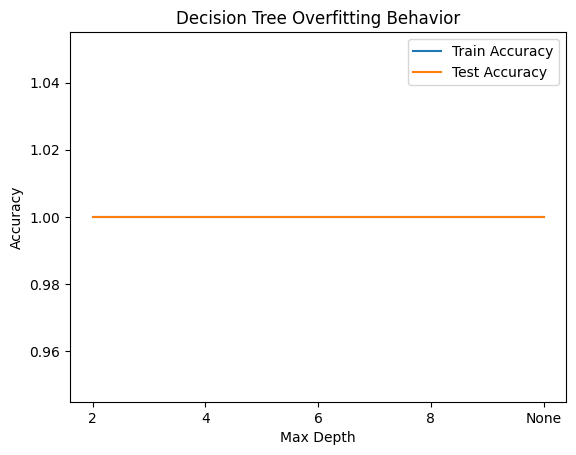

In [5]:
#DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# Experiment: Vary max_depth to Observe Overfitting
depths = [2, 4, 6, 8, None]
acc_train, acc_test = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    acc_train.append(model.score(X_train, y_train))
    acc_test.append(model.score(X_test, y_test))

plt.plot([str(d) for d in depths], acc_train, label='Train Accuracy')
plt.plot([str(d) for d in depths], acc_test, label='Test Accuracy')
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Behavior")
plt.legend()
plt.show()


Random Forest Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



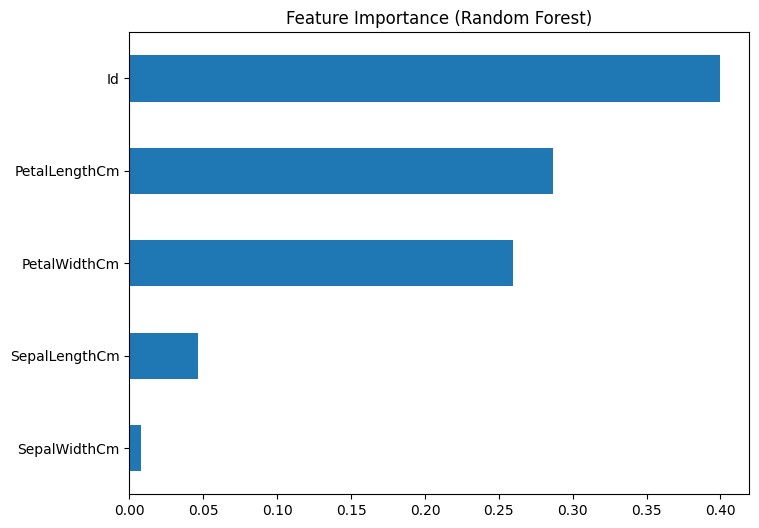

In [6]:
#random forest classifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Feature Importance Visualization
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [7]:
#boosting
# (a) AdaBoost Classifier
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report (AdaBoost):\n", classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 1.0

Classification Report (AdaBoost):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [8]:
# (b) Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report (Gradient Boosting):\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 1.0

Classification Report (Gradient Boosting):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [9]:
# Voting Classifier (Hard & Soft Voting)

lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Hard Voting
voting_hard = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('rf', rf)],
    voting='hard'
)
voting_hard.fit(X_train, y_train)
print("Hard Voting Accuracy:", accuracy_score(y_test, voting_hard.predict(X_test)))

# Soft Voting
voting_soft = VotingClassifier(
    estimators=[('lr', lr), ('knn', knn), ('rf', rf)],
    voting='soft'
)
voting_soft.fit(X_train, y_train)
print("Soft Voting Accuracy:", accuracy_score(y_test, voting_soft.predict(X_test)))

Hard Voting Accuracy: 1.0
Soft Voting Accuracy: 1.0


In [10]:
# Stacking Classifier (Meta-Learning)

base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('ada', AdaBoostClassifier(n_estimators=50, random_state=42))
]

meta_model = LogisticRegression()

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
print("Stacking Classifier Accuracy:", accuracy_score(y_test, y_pred_stack))
print("\nClassification Report (Stacking Classifier):\n", classification_report(y_test, y_pred_stack))

Stacking Classifier Accuracy: 1.0

Classification Report (Stacking Classifier):
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



/tmp/ipython-input-1044234695.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results.sort_values(by='Accuracy', ascending=True), palette='viridis')


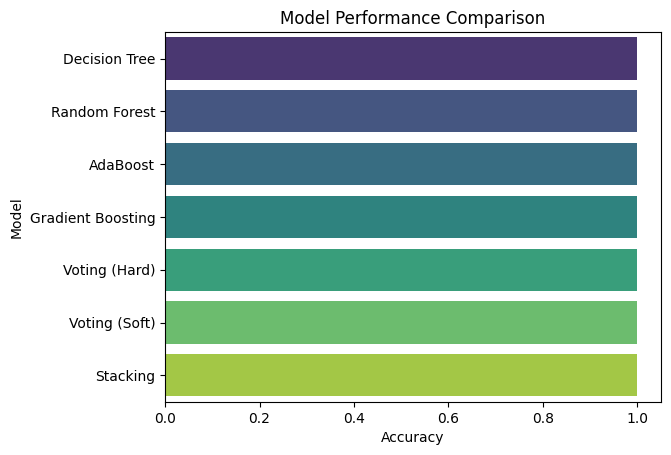

               Model  Accuracy
0      Decision Tree       1.0
1      Random Forest       1.0
2           AdaBoost       1.0
3  Gradient Boosting       1.0
4      Voting (Hard)       1.0
5      Voting (Soft)       1.0
6           Stacking       1.0


In [11]:
# Model Comparison Summary

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'AdaBoost', 'Gradient Boosting',
              'Voting (Hard)', 'Voting (Soft)', 'Stacking'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, voting_hard.predict(X_test)),
        accuracy_score(y_test, voting_soft.predict(X_test)),
        accuracy_score(y_test, y_pred_stack)
    ]
})

sns.barplot(x='Accuracy', y='Model', data=results.sort_values(by='Accuracy', ascending=True), palette='viridis')
plt.title("Model Performance Comparison")
plt.show()

print(results)